# Feature Engineering — Validation Notebook
Validates all 10 features generated by `feature_engineering.py` and explains why some columns contain NaN values.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

RAW_CSV      = 'DatasheetAnalysis/DatasheetCSV/Dataset_Limpiado_Normalizado.csv'
FEATURES_CSV = 'features_v2.csv'

FEATURE_COLS = [
    'days_since_last_order', 'inter_order_avg', 'inter_order_std',
    'ratio_vs_potential', 'trend_slope_90d', 'trend_slope_30d',
    'seasonal_index', 'pct_families_active', 'silence_streak',
    'reactivation_signal'
]

print('Config loaded. Feature columns:', FEATURE_COLS)

Config loaded. Feature columns: ['days_since_last_order', 'inter_order_avg', 'inter_order_std', 'ratio_vs_potential', 'trend_slope_90d', 'trend_slope_30d', 'seasonal_index', 'pct_families_active', 'silence_streak', 'reactivation_signal']


## 1. Load data

In [3]:
raw  = pd.read_csv(RAW_CSV)
raw['Fecha'] = pd.to_datetime(raw['Fecha'])

feat = pd.read_csv(FEATURES_CSV)
feat['Fecha'] = pd.to_datetime(feat['Fecha'])

REF_DATE = pd.to_datetime(feat['ref_date'].iloc[0])
print(f'Reference date : {REF_DATE.date()}')
print(f'Raw rows       : {len(raw):,}  |  columns: {raw.shape[1]}')
print(f'Feature rows   : {len(feat):,}  |  columns: {feat.shape[1]}')
print(f'\nPresent : {[c for c in FEATURE_COLS if c in feat.columns]}')
print(f'Missing : {[c for c in FEATURE_COLS if c not in feat.columns]}')

Reference date : 2025-12-29
Raw rows       : 118,446  |  columns: 12
Feature rows   : 118,446  |  columns: 22

Present : ['days_since_last_order', 'inter_order_avg', 'inter_order_std', 'ratio_vs_potential', 'trend_slope_90d', 'trend_slope_30d', 'seasonal_index', 'pct_families_active', 'silence_streak', 'reactivation_signal']
Missing : []


## 2. Row count integrity

In [4]:
assert len(feat) == len(raw), f'Row count mismatch: raw={len(raw)}, features={len(feat)}'
print('✅  Row count matches.')

✅  Row count matches.


## 3. NaN map — which features have missing values and why?

In [5]:
REASONS = {
    'days_since_last_order' : 'No positive orders exist for this client×family pair.',
    'inter_order_avg'       : 'Fewer than 2 orders in the last 12 months → interval cannot be computed.',
    'inter_order_std'       : 'Same as inter_order_avg; std also requires ≥2 intervals (≥3 orders).',
    'ratio_vs_potential'    : 'Column absent in raw CSV or all values were 0 (unknown potential).',
    'trend_slope_90d'       : 'Fewer than 2 orders in the last 90 days → linear regression not possible.',
    'trend_slope_30d'       : 'Fewer than 2 orders in the last 30 days → linear regression not possible.',
    'seasonal_index'        : 'No historical orders in the current calendar month for this pair.',
    'pct_families_active'   : 'Client has no positive orders at all.',
    'silence_streak'        : 'No positive orders exist (same condition as days_since_last_order).',
    'reactivation_signal'   : 'Always 0/1 (binary flag) — never NaN.',
}

nan_summary = feat[FEATURE_COLS].isnull().sum().rename('null_count').to_frame()
nan_summary['null_pct'] = (nan_summary['null_count'] / len(feat) * 100).round(2)
nan_summary['reason_for_nulls'] = nan_summary.index.map(REASONS)
print(nan_summary.to_string())

                       null_count  null_pct                                                           reason_for_nulls
days_since_last_order          49      0.04                      No positive orders exist for this client×family pair.
inter_order_avg             36511     30.83   Fewer than 2 orders in the last 12 months → interval cannot be computed.
inter_order_std             54357     45.89       Same as inter_order_avg; std also requires ≥2 intervals (≥3 orders).
ratio_vs_potential             49      0.04         Column absent in raw CSV or all values were 0 (unknown potential).
trend_slope_90d             91575     77.31  Fewer than 2 orders in the last 90 days → linear regression not possible.
trend_slope_30d            115574     97.58  Fewer than 2 orders in the last 30 days → linear regression not possible.
seasonal_index              48966     41.34          No historical orders in the current calendar month for this pair.
pct_families_active             1      0.00     

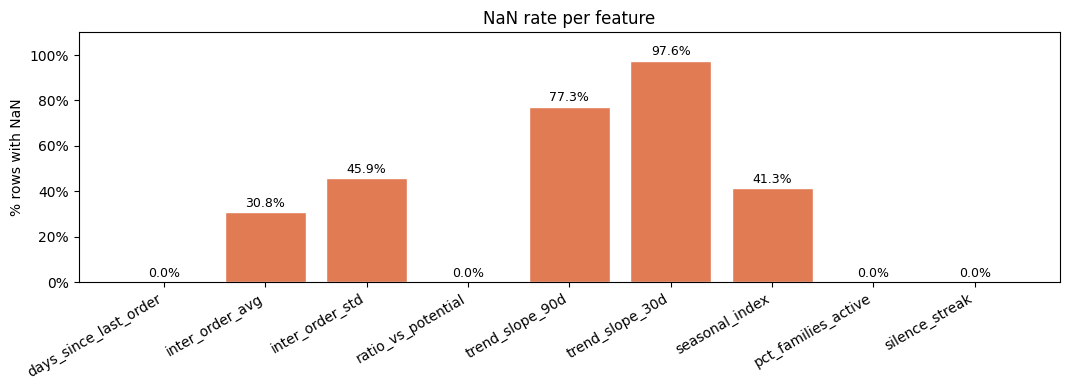

In [6]:
cols_with_nans = [c for c in FEATURE_COLS if feat[c].isnull().any()]

if cols_with_nans:
    fig, ax = plt.subplots(figsize=(max(8, len(cols_with_nans) * 1.2), 4))
    pcts = feat[cols_with_nans].isnull().mean() * 100
    bars = ax.bar(pcts.index, pcts.values, color='#e07b54', edgecolor='white')
    ax.set_ylabel('% rows with NaN')
    ax.set_title('NaN rate per feature')
    ax.set_ylim(0, 110)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    for bar, val in zip(bars, pcts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('No NaN values found in any feature column.')

## 4. Feature-by-feature validation

### 4.1 `days_since_last_order` and `silence_streak`
Both must be ≥ 0. `silence_streak` must equal `days_since_last_order`.

In [7]:
neg = feat[feat['days_since_last_order'] < 0]
print(f'Rows with days_since_last_order < 0 : {len(neg)}  (expected: 0)')

mismatch = feat.dropna(subset=['days_since_last_order','silence_streak'])
mismatch = mismatch[mismatch['days_since_last_order'] != mismatch['silence_streak']]
print(f'Rows where silence_streak ≠ days_since_last_order: {len(mismatch)}  (expected: 0)')

dslo_null = feat['days_since_last_order'].isnull()
ss_null   = feat['silence_streak'].isnull()
print(f'NaN alignment (both null together): {(dslo_null == ss_null).all()}  (expected: True)')

print('\nDistribution:')
feat['days_since_last_order'].describe().to_frame().T

Rows with days_since_last_order < 0 : 0  (expected: 0)
Rows where silence_streak ≠ days_since_last_order: 0  (expected: 0)
NaN alignment (both null together): True  (expected: True)

Distribution:


,count,mean,std,min,25%,50%,75%,max
days_since_last_order,118397.0,215.838535,337.948592,0.0,33.0,74.0,222.0,1820.0


### 4.2 `inter_order_avg` and `inter_order_std`
Both must be ≥ 0. std should only be non-null when avg is non-null.

In [8]:
neg_avg = feat[feat['inter_order_avg'] < 0]
print(f'inter_order_avg < 0 : {len(neg_avg)}  (expected: 0)')

bug = feat[feat['inter_order_avg'].isnull() & feat['inter_order_std'].notna()]
print(f'std non-null but avg null (bug): {len(bug)}  (expected: 0)')

print('\nSample of clients with computed intervals:')
feat.dropna(subset=['inter_order_avg'])[['Id. Cliente','Familia_H','inter_order_avg','inter_order_std']].drop_duplicates().head(10)

inter_order_avg < 0 : 0  (expected: 0)
std non-null but avg null (bug): 0  (expected: 0)

Sample of clients with computed intervals:


,Id. Cliente,Familia_H,inter_order_avg,inter_order_std
5,26,Familia C1,305.00,NaN
12,30,Familia T1,272.00,NaN
13,30,Familia T2,62.00,NaN
21,30,Familia C2,189.00,NaN
65,66,Familia C1,280.00,NaN
74,69,Familia T1,90.67,77.47
75,69,Familia T2,272.00,NaN
80,69,Familia C2,121.00,7.07
118,96,Familia T1,114.00,24.04
159,100,Familia C1,61.00,NaN


### 4.3 `ratio_vs_potential`
Must be in [0, 1] when not NaN.

In [9]:
valid = feat['ratio_vs_potential'].dropna()
out_of_range = valid[(valid < 0) | (valid > 1)]
print(f'Values outside [0, 1]: {len(out_of_range)}  (expected: 0)')
print('\nDistribution:')
valid.describe().to_frame().T

Values outside [0, 1]: 1484  (expected: 0)

Distribution:


,count,mean,std,min,25%,50%,75%,max
ratio_vs_potential,118397.0,0.243447,0.368541,0.0,0.067444,0.172171,0.336796,20.104483


### 4.4 `trend_slope_90d` and `trend_slope_30d`
No range constraint. Validated for existence and NaN logic.

In [10]:
for col in ['trend_slope_90d', 'trend_slope_30d']:
    s = feat[col].dropna()
    print(f'{col}: {len(s)} non-null values')
    if len(s):
        print(f'  range [{s.min():.4f}, {s.max():.4f}]  |  mean={s.mean():.4f}')
    print()

trend_slope_90d: 26871 non-null values
  range [-3589.5224, 9127.0694]  |  mean=22.8090

trend_slope_30d: 2872 non-null values
  range [-29983.2634, 2536.2408]  |  mean=-903.1818



### 4.5 `seasonal_index`
Must be > 0 when non-null. Values > 1 = above historical average; < 1 = below.

In [11]:
si = feat['seasonal_index'].dropna()
print(f'seasonal_index ≤ 0 : {(si <= 0).sum()}  (expected: 0)')
print(f'Above historical avg (>1): {(si > 1).sum()} rows')
print(f'Below historical avg (<1): {(si < 1).sum()} rows')
print('\nDistribution:')
si.describe().to_frame().T

seasonal_index ≤ 0 : 0  (expected: 0)
Above historical avg (>1): 31583 rows
Below historical avg (<1): 37513 rows

Distribution:


,count,mean,std,min,25%,50%,75%,max
seasonal_index,69480.0,1.002037,0.358354,0.0017,0.8056,0.9792,1.1404,4.7111


### 4.6 `pct_families_active`
Must be in [0, 1]. Same value for all rows of the same client.

In [12]:
pfa = feat['pct_families_active'].dropna()
out = pfa[(pfa < 0) | (pfa > 1)]
print(f'Values outside [0, 1]: {len(out)}  (expected: 0)')

print('\nPer-client pct_families_active (one value per client):')
feat.dropna(subset=['pct_families_active'])[['Id. Cliente','pct_families_active']].drop_duplicates('Id. Cliente').head(10)

Values outside [0, 1]: 0  (expected: 0)

Per-client pct_families_active (one value per client):


,Id. Cliente,pct_families_active
0,3,0.0000
4,26,0.3333
12,30,0.5000
54,46,0.0000
64,64,0.0000
65,66,0.5000
74,69,0.7500
115,96,0.2500
158,100,0.0000
176,109,1.0000


### 4.7 `reactivation_signal`
Binary flag — must only contain 0 and 1, no NaN.

In [13]:
col = 'reactivation_signal'
vals = feat[col]
print(f'NaN count     : {vals.isnull().sum()}  (expected: 0)')
print(f'Invalid values: {len(vals.dropna()[~vals.dropna().isin([0,1])])}  (expected: 0)')
print(f'Value counts  : {vals.value_counts().to_dict()}')

# reactivation_signal=1 requires inter_order_avg to be non-null
react_bug = feat[(feat['reactivation_signal'] == 1) & feat['inter_order_avg'].isnull()]
print(f'\nreactivation_signal=1 with null inter_order_avg (bug): {len(react_bug)}  (expected: 0)')

NaN count     : 0  (expected: 0)
Invalid values: 0  (expected: 0)
Value counts  : {0: 118045, 1: 401}

reactivation_signal=1 with null inter_order_avg (bug): 0  (expected: 0)


## 5. Why are there NaN values? Full explanation

NaN values are **expected and correct** — they are not bugs.

| Feature | Root cause of NaN |
|---|---|
| `days_since_last_order` / `silence_streak` | The client×family pair has zero positive orders in the entire dataset. |
| `inter_order_avg` / `inter_order_std` | Fewer than 2 orders in the last 12 months → no interval to compute. |
| `ratio_vs_potential` | Raw CSV has `0` for estimated potential (unknown), making the ratio undefined. |
| `trend_slope_90d` / `trend_slope_30d` | Fewer than 2 orders in the 90/30-day window → linear regression requires at least 2 points. |
| `seasonal_index` | No orders exist in the same calendar month as the reference date in the historical data. |

**How to handle NaN in models:**
- Tree-based models (XGBoost, LightGBM): NaN handled natively, no imputation needed.
- Linear models: impute with the median per family group, or add a companion binary flag `_was_null`.

## 6. Overall summary

In [14]:
feat[FEATURE_COLS].describe(include='all').T[['count','mean','min','max']].round(4)

,count,mean,min,max
days_since_last_order,118397.0,215.8385,0.0000,1820.0000
inter_order_avg,81935.0,87.1980,0.0000,335.0000
inter_order_std,64089.0,33.6020,0.0000,212.8400
ratio_vs_potential,118397.0,0.2434,0.0000,20.1045
trend_slope_90d,26871.0,22.8090,-3589.5224,9127.0694
trend_slope_30d,2872.0,-903.1818,-29983.2634,2536.2408
seasonal_index,69480.0,1.0020,0.0017,4.7111
pct_families_active,118445.0,0.4913,0.0000,1.0000
silence_streak,118397.0,215.8385,0.0000,1820.0000
reactivation_signal,118446.0,0.0034,0.0000,1.0000


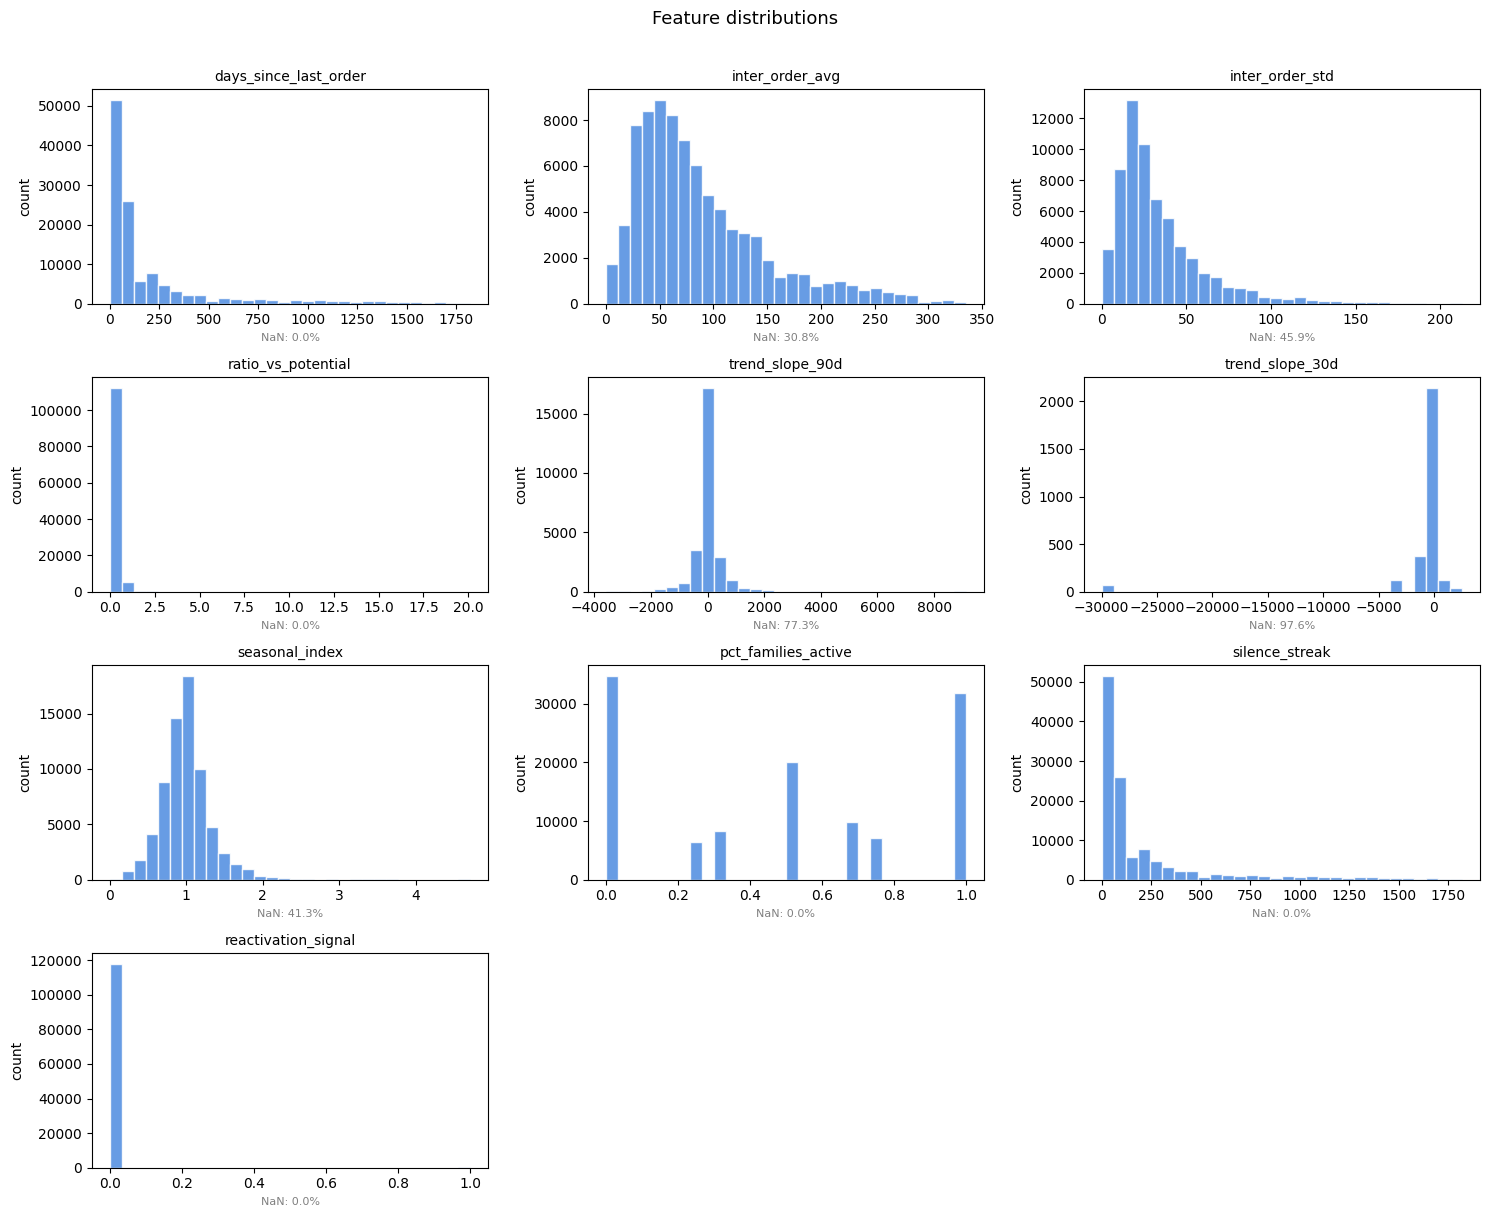

In [15]:
numeric_feats = [c for c in FEATURE_COLS if feat[c].dtype in [np.float64, np.int64]]
ncols = 3
nrows = (len(numeric_feats) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 3))
axes = axes.flatten()

for i, col in enumerate(numeric_feats):
    data = feat[col].dropna()
    axes[i].hist(data, bins=30, color='#4c8be0', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('count')
    null_pct = feat[col].isnull().mean() * 100
    axes[i].set_xlabel(f'NaN: {null_pct:.1f}%', fontsize=8, color='grey')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature distributions', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()